# **Data Collection Notebook**

## Objectives

* Fetch data from Kaggle and save it as raw data.
* Inspect the data and save it under `outputs/datasets/collection`

## Inputs

* Kaggle JSON file — the authentication token.

## Outputs

* Generate Dataset: `outputs/datasets/collection/ai_job_dataset1.csv`

## Additional Comments

* Dataset: **Global AI Job Market & Salary Trends 2025** by Bisma Sajjad on Kaggle.
* 15,000+ synthetic job listings from 50+ countries with 20 features.
* In the workplace, data is not pushed to public repositories for security reasons.


## Imports

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import zipfile
import pandas as pd

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.
* We access the current directory with `os.getcwd()`

In [2]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory.
* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index'

# Fetch data from Kaggle

Install the Kaggle package to fetch data.

In [17]:
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


You need a `kaggle.json` file (authentication token) in the project root.
* Download it from your Kaggle account under **Account → API → Create New API Token**.

In [6]:
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()

Define the Kaggle dataset path and the destination folder, then download it.

In [7]:
KaggleDatasetPath = "bismasajjad/global-ai-job-market-and-salary-trends-2025"
DestinationFolder = "inputs/datasets/raw"
os.makedirs(DestinationFolder, exist_ok=True)

! kaggle datasets download -d {KaggleDatasetPath} -p {DestinationFolder} # noqa: E225

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config,auth} ...
kaggle: error: unrecognized arguments: noqa: E225


Unzip the downloaded file.

In [8]:
# Find all zip files in the folder
zip_files = glob.glob(os.path.join(DestinationFolder, "*.zip"))

# Extract each zip file and then delete it
for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DestinationFolder)
    os.remove(zip_path)

# Remove kaggle.json if it exists to avoid exposing credentials
kaggle_json = os.path.join(os.getcwd(), "kaggle.json")
if os.path.exists(kaggle_json):
    os.remove(kaggle_json)

print("All ZIP files extracted and deleted.")

All ZIP files extracted and deleted.


# Inspect the data

In [9]:
df = pd.read_csv(f"{DestinationFolder}/ai_job_dataset1.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (15000, 20)


,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


Check data types and missing values.

## data type:

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   salary_local            15000 non-null  int64  
 5   experience_level        15000 non-null  object 
 6   employment_type         15000 non-null  object 
 7   company_location        15000 non-null  object 
 8   company_size            15000 non-null  object 
 9   employee_residence      15000 non-null  object 
 10  remote_ratio            15000 non-null  int64  
 11  required_skills         15000 non-null  object 
 12  education_required      15000 non-null  object 
 13  years_experience        15000 non-null  int64  
 14  industry                15000 non-null

The dataset consists of 20 variables. All data types are correctly assigned:

- **6 Numerical variables** are stored as either int64 or float64
- **14 Categorical variables** are stored as object type
- **Target variable** `salary_usd` is numerical (int64)
This indicates that the dataset is properly typed, with no immediate data type conversions required before preprocessing.

## Duplicates

In [11]:
df[df.duplicated(keep=False)]

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name


Dataset has no duplicates values

## Missing values

In [12]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

Dataset has no Missing Values

## Summary statistics

In [13]:
df.describe()

,salary_usd,salary_local,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000
mean,121991.938267,8.292366e+05,50.196667,6.365667,1500.852600,7.499540
std,63968.361846,3.425325e+06,40.844084,5.598551,574.724647,1.444202
min,16621.000000,1.662100e+04,0.000000,0.000000,500.000000,5.000000
25%,74978.500000,7.383075e+04,0.000000,2.000000,998.750000,6.300000
50%,107261.500000,1.090355e+05,50.000000,5.000000,1512.000000,7.500000
75%,155752.250000,1.673278e+05,100.000000,10.000000,1994.000000,8.800000
max,410273.000000,3.368541e+07,100.000000,19.000000,2499.000000,10.000000


**Key observations from summary statistics:**

* **`salary_usd`** : Mean ~$122k, max $410k. The large standard deviation (~$64k) reflects the global spread of salaries across countries and roles. This is the primary target variable for analysis.
* **`salary_local`** : Very high std and max values. This is expected since it mixes different currencies (USD, JPY, EUR, etc.) making direct comparisons unreliable. Not suitable for modelling as-is.
* **`remote_ratio`** : Takes only 3 values: 0 (on-site), 50 (hybrid), 100 (fully remote). The mean of ~50 suggests a fairly balanced distribution across the three categories.
* **`years_experience`** : Ranges from 0 to 19, mean ~6.4. No negative or unrealistic values, the column looks clean.
* **`job_description_length`** : Ranges from 500 to 2499, roughly uniform. Unlikely to be a useful predictor.
* **`benefits_score`** : Ranges from 5 to 10, mean 7.5. No zeros or invalid entries.

**Overall:** No obvious data quality issues (no negative salaries, no placeholder values like 999). The suspiciously uniform distributions across columns are consistent with the dataset being synthetic.

## Distribusion visualisation

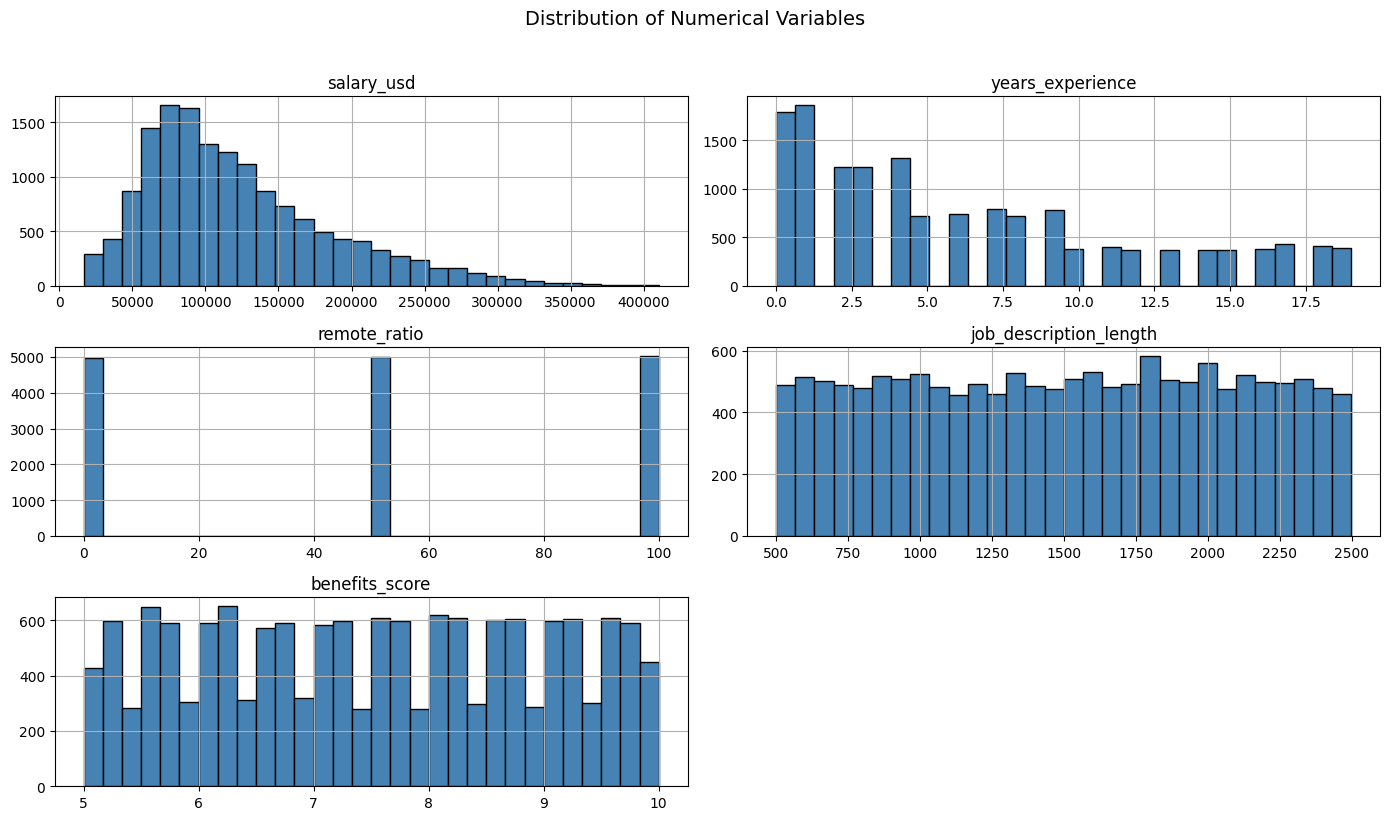

In [14]:
df[['salary_usd', 'years_experience', 'remote_ratio',
    'job_description_length', 'benefits_score']].hist(
    figsize=(14, 8), bins=30, edgecolor='black', color='steelblue'
)
plt.suptitle("Distribution of Numerical Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

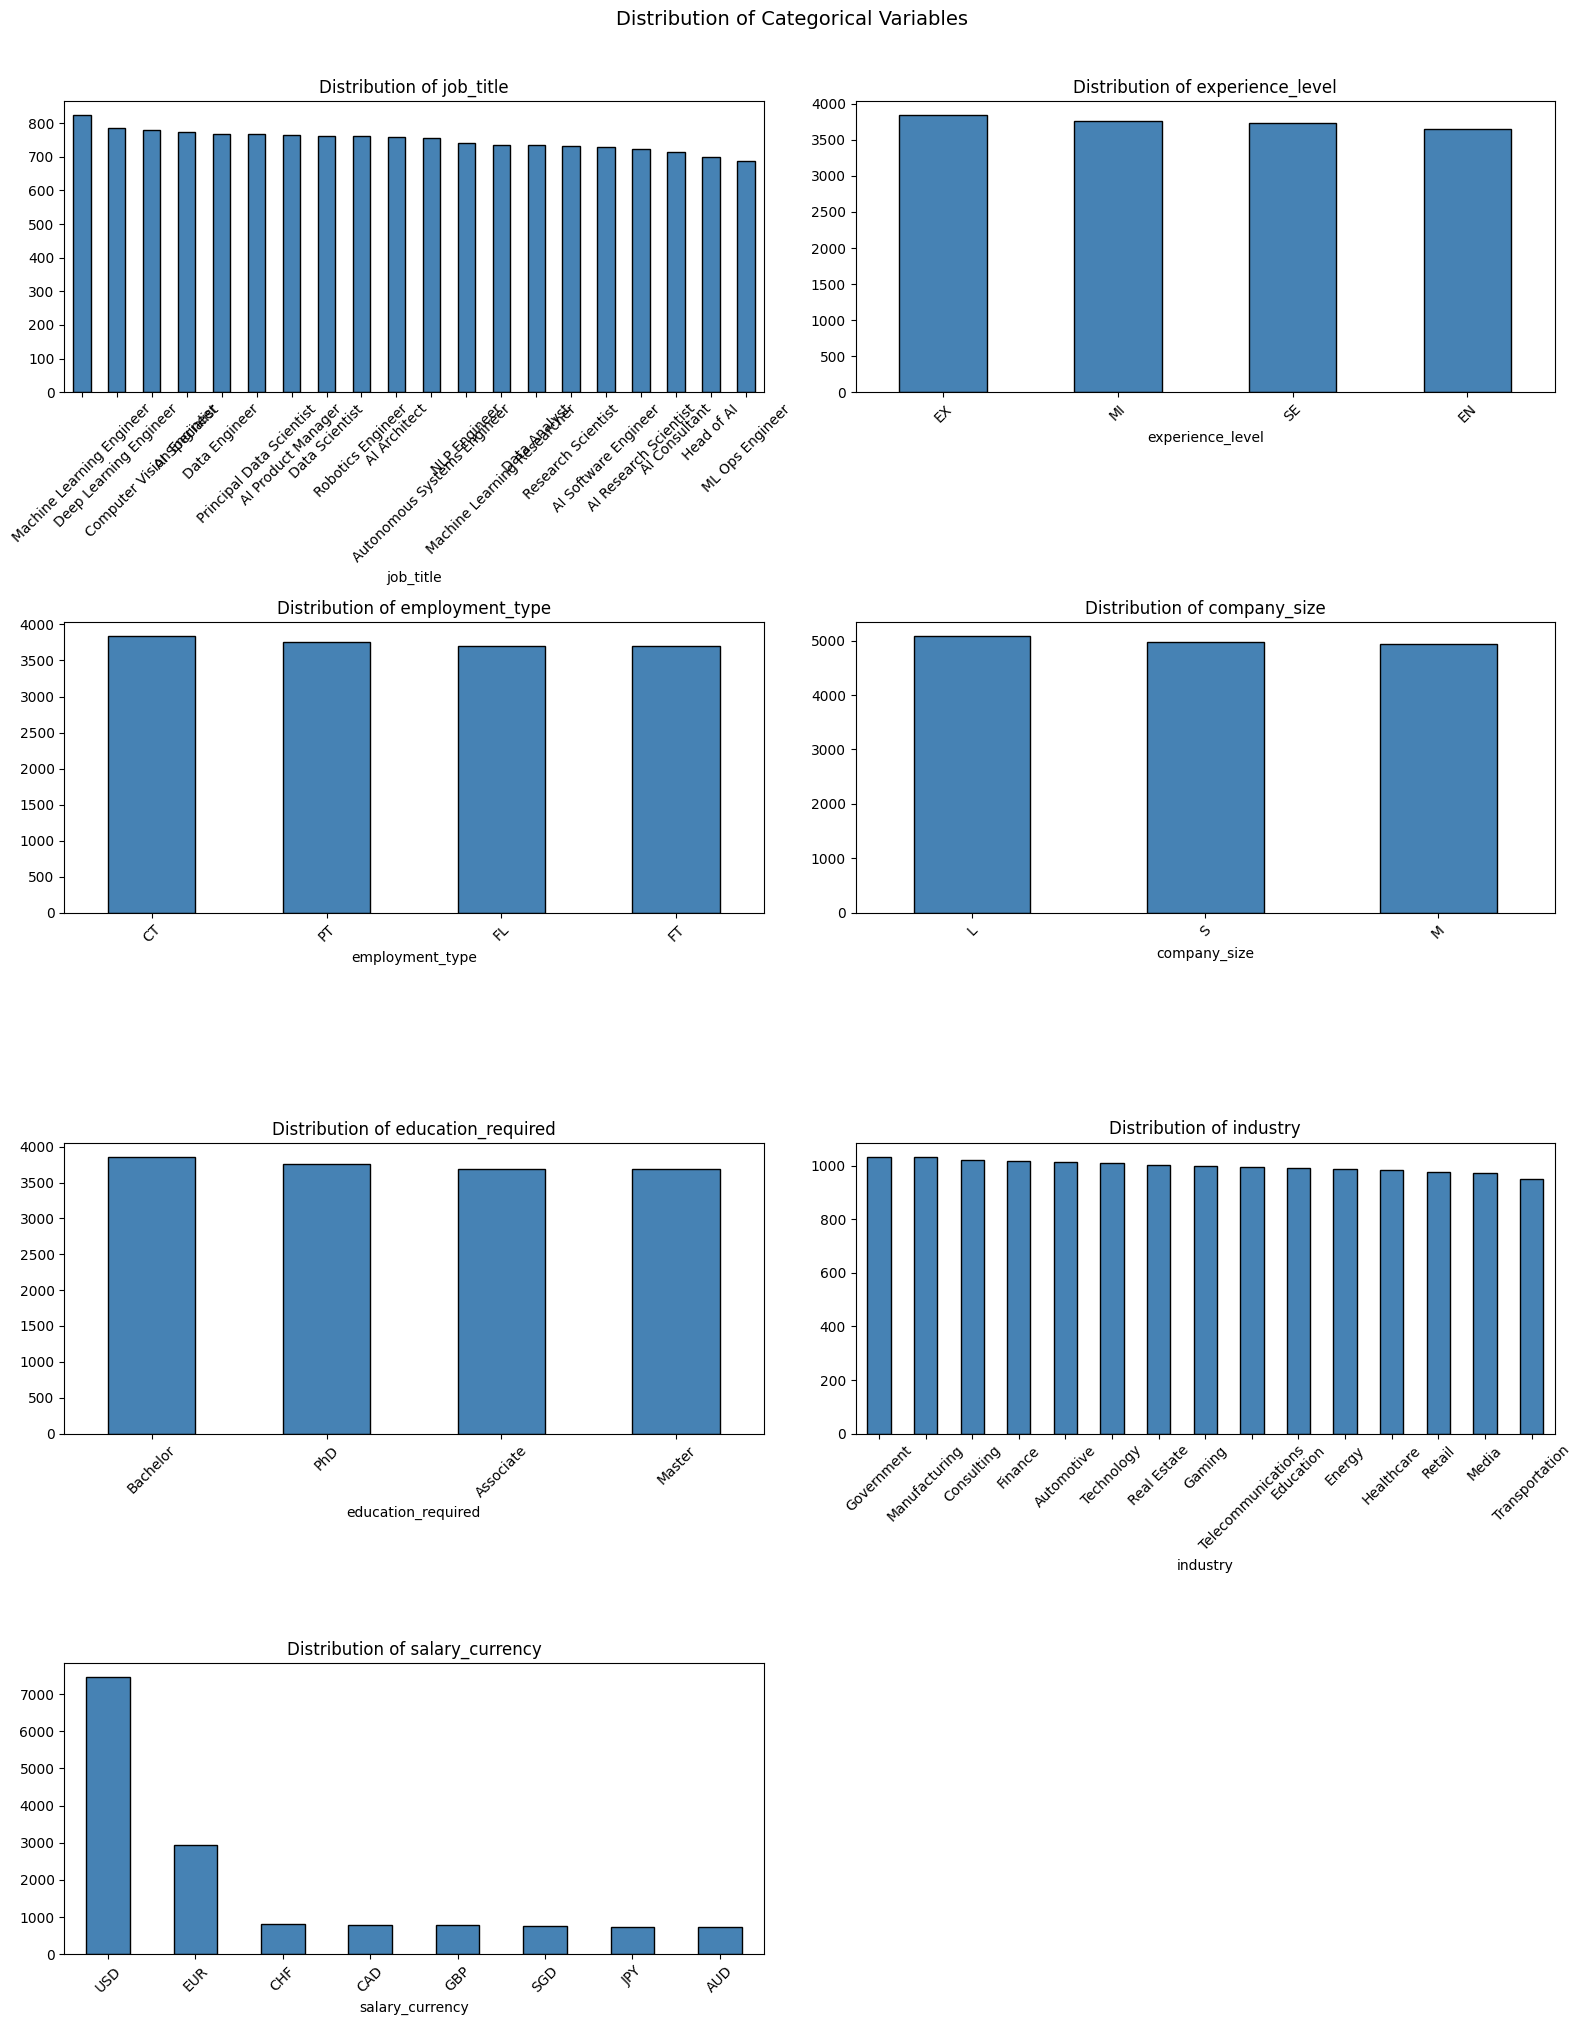

In [15]:
cat_cols = ['job_title', 'experience_level', 'employment_type', 'company_size',
            'education_required', 'industry', 'salary_currency']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue',
                                edgecolor='black')
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)  # hide the unused 8th subplot
plt.suptitle("Distribution of Categorical Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Note**
`company_location`, `employee_residence`, and `company_name` are excluded since they have too many unique values to display clearly in a bar chart.

---

# Push files to Repo

In [16]:
# create outputs/datasets/collection folder
try:
    os.makedirs(name='outputs/datasets/collection')
except Exception as e:
    print(e)

df.to_csv(f"outputs/datasets/collection/ai_job_dataset1.csv", index=False)

[WinError 183] Cannot create a file when that file already exists: 'outputs/datasets/collection'


# Conclusions and Next Steps

The dataset is well-structured with 15,000 rows, 20 features, no missing values, and no duplicated rows. All data types are correctly assigned. Distribution plots confirm that most numerical and categorical variables are uniformly distributed, consistent with the synthetic nature of the dataset. `salary_local` is unreliable for modelling due to mixed currencies and will be excluded. No immediate data quality issues were identified; the data is ready for exploratory analysis and preprocessing.

* Next step: **02 - JobMarketStudy** — Exploratory Data Analysis and correlation study.